In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

In [15]:
CSV_PATH = Path('../results/swna/exponential swna.csv')
df = pd.read_csv(CSV_PATH)
df.head()

,planet,transit,model,r_squared,regime,mu,nu,N,beta
0,CoRoT-01,CoRoT-01_T01,exponential,0.780158,subdiffusive,0.880945,NaN,0.011295,27.045403
1,CoRoT-01,CoRoT-01_T02,exponential,0.882225,superdiffusive,1.411565,NaN,0.000034,0.754242
2,CoRoT-01,CoRoT-01_T03,exponential,0.850675,superdiffusive,1.307765,NaN,0.001647,8.138700
3,CoRoT-01,CoRoT-01_T04,exponential,0.806412,subdiffusive,0.866846,NaN,0.011243,25.849996
4,CoRoT-01,CoRoT-01_T05,exponential,0.887890,superdiffusive,1.320655,NaN,0.000217,2.080339


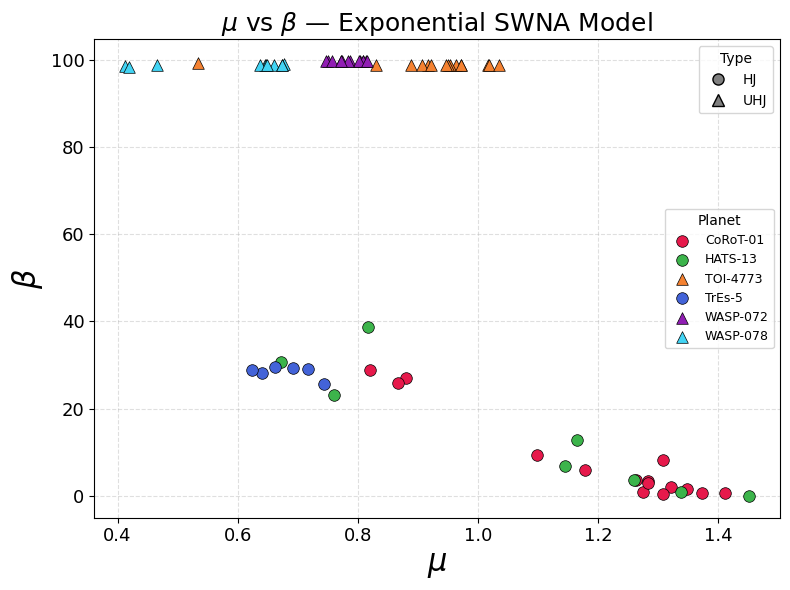

Saved --> results/swna/mu_vs_beta_scatter.png


In [16]:
# ── Classification ────────────────────────────────────────────────────────────
HJ  = {'TrEs-5', 'CoRoT-01', 'HATS-13'}
UHJ = {'TOI-4773', 'WASP-072', 'WASP-078'}

PLANET_COLORS = {
    'CoRoT-01': '#e6194b',
    'HATS-13':  '#3cb44b',
    'TrEs-5':   '#4363d8',
    'TOI-4773': '#f58231',
    'WASP-072': '#911eb4',
    'WASP-078': '#42d4f4',
}

fig, ax = plt.subplots(figsize=(8, 6))

for planet, group in df.groupby('planet'):
    color  = PLANET_COLORS.get(planet, 'gray')
    marker = 'o' if planet in HJ else '^'
    ax.scatter(
        group['mu'], group['beta'],
        color=color, marker=marker,
        s=70, edgecolors='k', linewidths=0.5,
        label=planet, zorder=3,
    )

ax.set_xlabel(r'$\mu$', fontsize=22)
ax.set_ylabel(r'$\beta$', fontsize=22)
ax.set_title(r'$\mu$ vs $\beta$ — Exponential SWNA Model', fontsize=18)
ax.tick_params(axis='both', labelsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

# ── Legend: planets (color) + shape key (HJ/UHJ) ─────────────────────────────
planet_legend = ax.legend(
    title='Planet', loc='center right',
    fontsize=9, title_fontsize=10,
    framealpha=0.8,
)
ax.add_artist(planet_legend)

hj_handle  = mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
                            markeredgecolor='k', markersize=8, label='HJ')
uhj_handle = mlines.Line2D([], [], color='gray', marker='^', linestyle='None',
                            markeredgecolor='k', markersize=8, label='UHJ')
ax.legend(handles=[hj_handle, uhj_handle], title='Type',
          loc='upper right', fontsize=10, title_fontsize=10)

plt.tight_layout()
plt.savefig('../results/swna/mu_vs_beta_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> results/swna/mu_vs_beta_scatter.png')

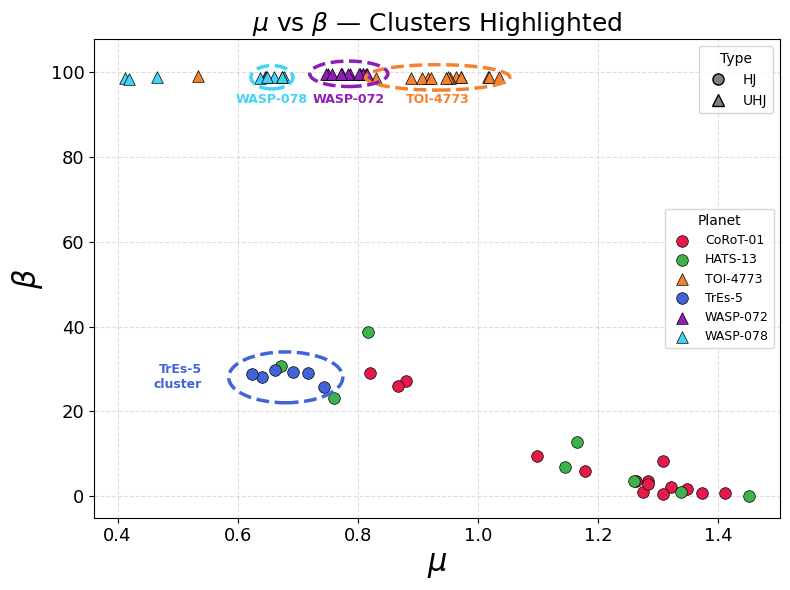

Saved --> results/swna/mu_vs_beta_clusters.png


In [17]:
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

for planet, group in df.groupby('planet'):
    color  = PLANET_COLORS.get(planet, 'gray')
    marker = 'o' if planet in HJ else '^'
    ax.scatter(
        group['mu'], group['beta'],
        color=color, marker=marker,
        s=70, edgecolors='k', linewidths=0.5,
        label=planet, zorder=3,
    )

# ── Per-planet UHJ ellipses (outliers excluded) ───────────────────────────────
# TOI-4773: main cluster T07–T10 (μ=0.83–1.04), excludes T05 (μ=0.533)
# WASP-072: all points tight (μ=0.747–0.815), no outliers
# WASP-078: main cluster T07–T05 (μ=0.637–0.677), excludes T04, T11, T01
uhj_clusters = {
    'TOI-4773': dict(xy=(0.933, 98.798), width=0.24, height=6.0, label_xy=(0.933, 95.2)),
    'WASP-072': dict(xy=(0.785, 99.647), width=0.13, height=6.0, label_xy=(0.785, 95.2)),
    'WASP-078': dict(xy=(0.657, 98.826), width=0.07, height=5.5, label_xy=(0.657, 95.2)),
}

for planet, cfg in uhj_clusters.items():
    color = PLANET_COLORS[planet]
    ellipse = mpatches.Ellipse(
        xy=cfg['xy'], width=cfg['width'], height=cfg['height'],
        angle=0, fill=False, edgecolor=color, linewidth=2.5, linestyle='--', zorder=4,
    )
    ax.add_patch(ellipse)
    ax.text(
        cfg['label_xy'][0], cfg['label_xy'][1],
        planet, fontsize=9, color=color, va='top', ha='center', fontweight='bold',
    )

# ── TrEs-5 HJ sub-cluster (label on the left) ────────────────────────────────
tres_ellipse = mpatches.Ellipse(
    xy=(0.68, 28.0), width=0.19, height=12.0,
    angle=0, fill=False, edgecolor='#4363d8', linewidth=2.5, linestyle='--', zorder=4,
)
ax.add_patch(tres_ellipse)
ax.text(0.54, 28.0, 'TrEs-5\ncluster', fontsize=9, color='#4363d8', va='center',
        ha='right', fontweight='bold')

ax.set_xlabel(r'$\mu$', fontsize=22)
ax.set_ylabel(r'$\beta$', fontsize=22)
ax.set_title(r'$\mu$ vs $\beta$ — Clusters Highlighted', fontsize=18)
ax.tick_params(axis='both', labelsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

planet_legend = ax.legend(
    title='Planet', loc='center right',
    fontsize=9, title_fontsize=10, framealpha=0.8,
)
ax.add_artist(planet_legend)

hj_handle  = mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
                            markeredgecolor='k', markersize=8, label='HJ')
uhj_handle = mlines.Line2D([], [], color='gray', marker='^', linestyle='None',
                            markeredgecolor='k', markersize=8, label='UHJ')
ax.legend(handles=[hj_handle, uhj_handle], title='Type',
          loc='upper right', fontsize=10, title_fontsize=10)

plt.tight_layout()
plt.savefig('../results/swna/mu_vs_beta_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> results/swna/mu_vs_beta_clusters.png')

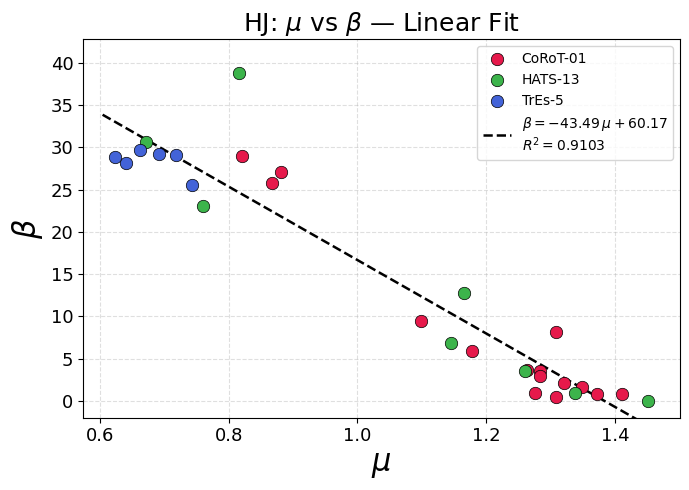

Linear fit: β = -43.4924·μ + 60.1675  |  R² = 0.9103
Saved --> results/swna/mu_vs_beta_HJ_linearfit.png


In [18]:
# ── Zoom-in on HJ inverse μ–β trend with linear fit ──────────────────────────
hj_df = df[df['planet'].isin(HJ)].copy()

# Linear fit
coeffs = np.polyfit(hj_df['mu'], hj_df['beta'], 1)
slope, intercept = coeffs
mu_fit = np.linspace(hj_df['mu'].min() - 0.02, hj_df['mu'].max() + 0.02, 200)
beta_fit = np.polyval(coeffs, mu_fit)

# R²
beta_pred = np.polyval(coeffs, hj_df['mu'])
ss_res = np.sum((hj_df['beta'] - beta_pred) ** 2)
ss_tot = np.sum((hj_df['beta'] - hj_df['beta'].mean()) ** 2)
r2 = 1 - ss_res / ss_tot

sign = '+' if intercept >= 0 else '-'
eq_str = rf'$\beta = {slope:.2f}\,\mu {sign} {abs(intercept):.2f}$' + f'\n$R^2 = {r2:.4f}$'

fig, ax = plt.subplots(figsize=(7, 5))

for planet, group in hj_df.groupby('planet'):
    ax.scatter(
        group['mu'], group['beta'],
        color=PLANET_COLORS[planet], marker='o',
        s=80, edgecolors='k', linewidths=0.5,
        label=planet, zorder=3,
    )

ax.plot(mu_fit, beta_fit, color='black', linewidth=1.8, linestyle='--',
        label=eq_str, zorder=2)

ax.set_xlabel(r'$\mu$', fontsize=22)
ax.set_ylabel(r'$\beta$', fontsize=22)
ax.set_title(r'HJ: $\mu$ vs $\beta$ — Linear Fit', fontsize=18)
ax.tick_params(axis='both', labelsize=13)
ax.set_xlim(hj_df['mu'].min() - 0.05, hj_df['mu'].max() + 0.05)
ax.set_ylim(-2, hj_df['beta'].max() + 4)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.savefig('../results/swna/mu_vs_beta_HJ_linearfit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Linear fit: β = {slope:.4f}·μ + {intercept:.4f}  |  R² = {r2:.4f}')
print('Saved --> results/swna/mu_vs_beta_HJ_linearfit.png')